In [1]:
# Testing the kernel

print("hello world")

hello world


In [2]:
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Add src to path to import our modules
sys.path.append(os.path.abspath("../src"))

import config
from dataset import HubbleDataProcessor, HubbleDataset
from model import ZeroTrustAutoencoder

print("Environment Ready.")


Environment Ready.


🐝 Loading raw Hubble logs from /home/diaa/AuraNet/monolith_training/data/raw/hubble_training_data.json...
✅ Filtered down to 100 pure, relevant network events.
🧠 Engineered Feature Matrix: 9 dimensions.
 Simulating Training to capture Loss Curve...


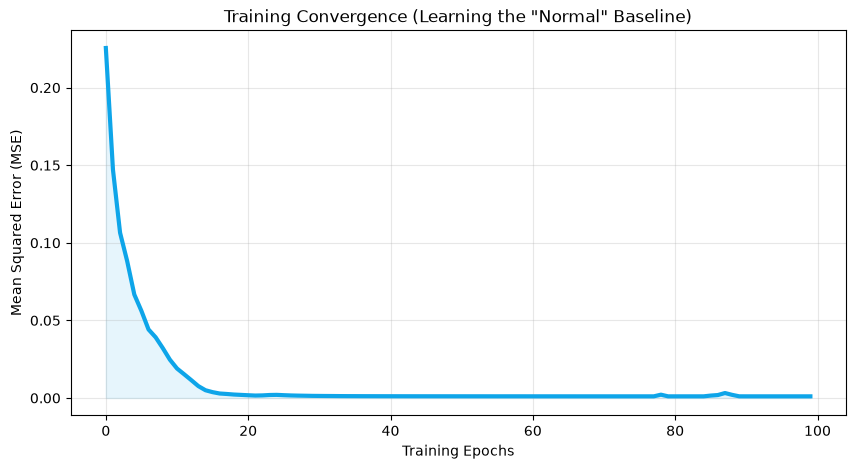

In [3]:

processor = HubbleDataProcessor(config.TRAIN_DATA_PATH)
processor.load_and_filter()
processor.engineer_features()
df_train = processor.get_dataframe()

input_dim = df_train.shape[1]
train_loader = DataLoader(HubbleDataset(df_train), batch_size=8, shuffle=True)


live_model = ZeroTrustAutoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(live_model.parameters(), lr=0.01)

epoch_history = []
loss_history = []

print(" Simulating Training to capture Loss Curve...")
for epoch in range(100):
    total_loss = 0
    for batch_features, _ in train_loader:
        reconstructed = live_model(batch_features)
        loss = criterion(reconstructed, batch_features)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    epoch_history.append(epoch)
    loss_history.append(avg_loss)


plt.figure(figsize=(10, 5))
plt.plot(epoch_history, loss_history, color='#0ea5e9', linewidth=3)
plt.title('Training Convergence (Learning the "Normal" Baseline)')
plt.xlabel('Training Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True, alpha=0.3)
plt.fill_between(epoch_history, loss_history, color='#0ea5e9', alpha=0.1)
plt.show()


🐝 Loading raw Hubble logs from /home/diaa/AuraNet/monolith_training/data/raw/hubble_attack_data.json...
✅ Filtered down to 26 pure, relevant network events.
🧠 Engineered Feature Matrix: 9 dimensions.


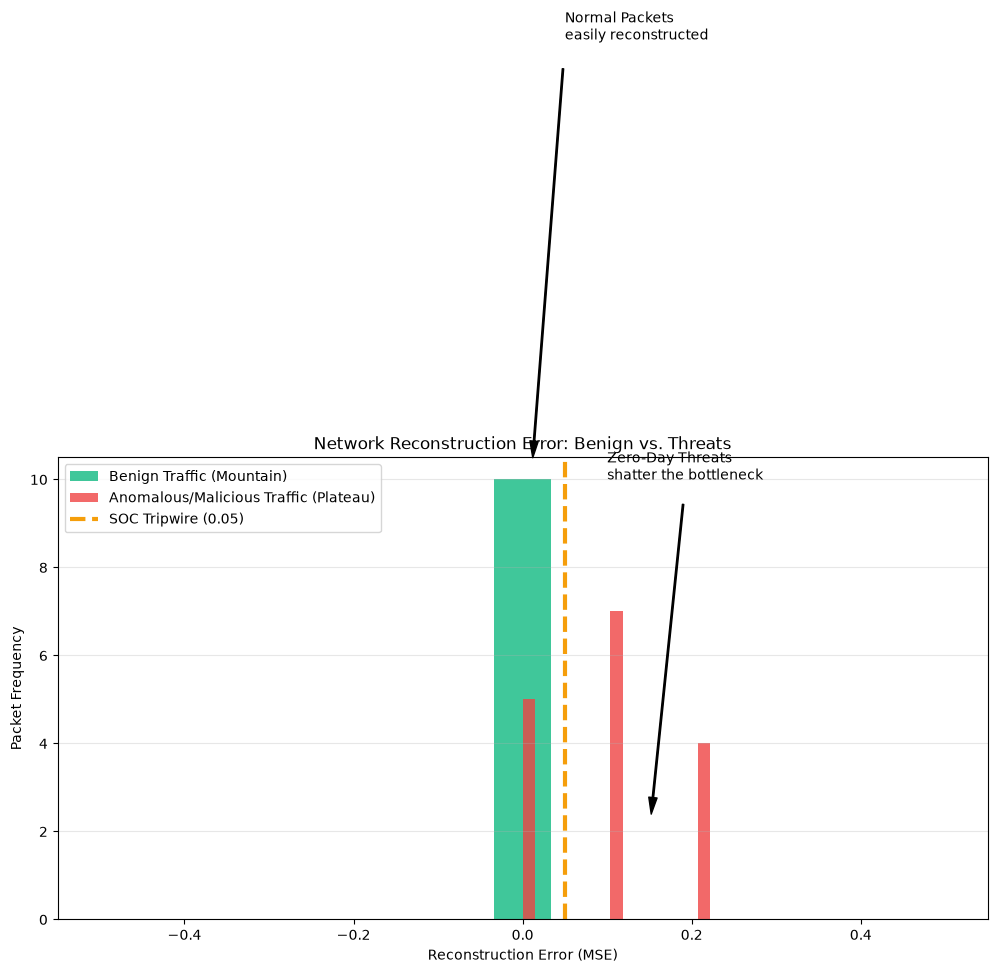

In [6]:
### this is not done yet please ignore



test_processor = HubbleDataProcessor(config.TEST_DATA_PATH)
test_processor.load_and_filter()
test_processor.engineer_features()
df_test = test_processor.get_dataframe()
raw_events = test_processor.raw_data


normal_mses = []
anomaly_mses = []


live_model.eval()

for i in range(len(df_test)):
    row_tensor = torch.FloatTensor(df_test.iloc[i].values)
    context = raw_events[i]
    
    with torch.no_grad():
        reconstructed = live_model(row_tensor)
        mse_loss = criterion(reconstructed, row_tensor).item()
        
    # Heuristic for the plot: Separate known attacks from normal traffic
    if context['method'] in ['POST', 'DELETE'] or df_test.iloc[i]['is_valid_path'] == 0.0:
        anomaly_mses.append(mse_loss)
    else:
        normal_mses.append(mse_loss)

# 3. Plot Diagram 2
plt.figure(figsize=(12, 6))

# The "Tall Mountain Near Zero"
plt.hist(normal_mses, bins=15, alpha=0.8, color='#10b981', label='Benign Traffic (Mountain)')

# The "Far Plateaued Hill"
plt.hist(anomaly_mses, bins=15, alpha=0.8, color='#ef4444', label='Anomalous/Malicious Traffic (Plateau)')

# The Tripwire
plt.axvline(x=0.05, color='#f59e0b', linestyle='--', linewidth=3, label='SOC Tripwire (0.05)')

plt.title('Network Reconstruction Error: Benign vs. Threats')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Packet Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.annotate('Normal Packets\neasily reconstructed', xy=(0.01, 10), xytext=(0.05, 20),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.annotate('Zero-Day Threats\nshatter the bottleneck', xy=(0.15, 2), xytext=(0.10, 10),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.show()


🚀 Running Hyperparameter Grid Search (Learning Rates)...


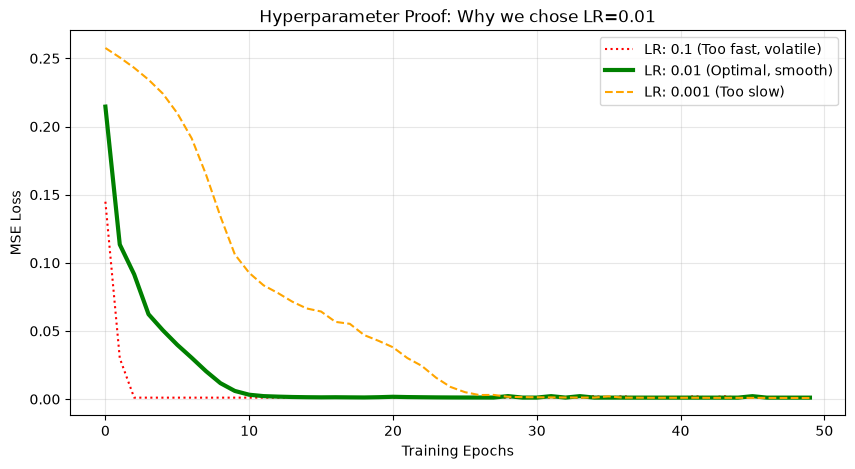

In [7]:
learning_rates = [0.1, 0.01, 0.001]
lr_loss_history = {lr: [] for lr in learning_rates}

print("🚀 Running Hyperparameter Grid Search (Learning Rates)...")

for lr in learning_rates:
    temp_model = ZeroTrustAutoencoder(input_dim)
    optimizer = optim.Adam(temp_model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    for epoch in range(50): # 50 epochs is enough to see the trend
        total_loss = 0
        for batch_features, _ in train_loader:
            optimizer.zero_grad()
            loss = criterion(temp_model(batch_features), batch_features)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        lr_loss_history[lr].append(total_loss / len(train_loader))

plt.figure(figsize=(10, 5))
plt.plot(lr_loss_history[0.1], label='LR: 0.1 (Too fast, volatile)', color='red', linestyle=':')
plt.plot(lr_loss_history[0.01], label='LR: 0.01 (Optimal, smooth)', color='green', linewidth=3)
plt.plot(lr_loss_history[0.001], label='LR: 0.001 (Too slow)', color='orange', linestyle='--')

plt.title('Hyperparameter Proof: Why we chose LR=0.01')
plt.xlabel('Training Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


🚀 Running Architecture Search (Latent Space Dimensions)...


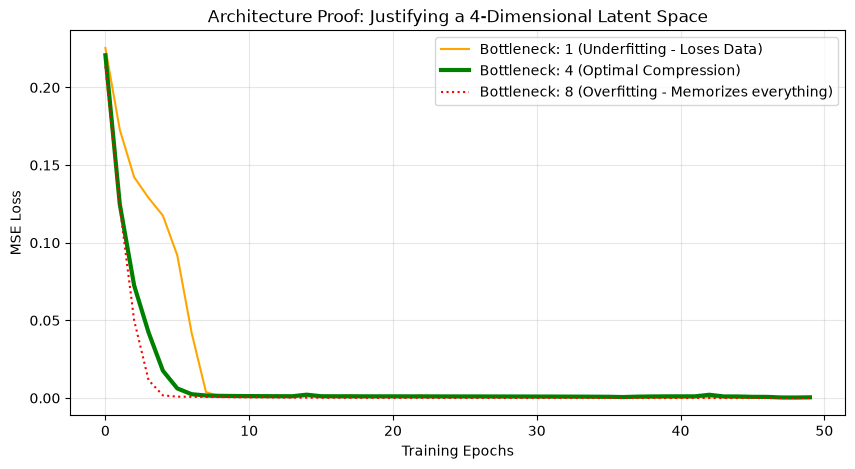

In [12]:
# Create custom autoencoders with different bottleneck sizes
class CustomAE(nn.Module):
    def __init__(self, input_dim, bottleneck_size):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 8), nn.ReLU(), nn.Linear(8, bottleneck_size))
        self.decoder = nn.Sequential(nn.Linear(bottleneck_size, 8), nn.ReLU(), nn.Linear(8, input_dim), nn.Sigmoid())
    def forward(self, x): return self.decoder(self.encoder(x))

bottlenecks = [1, 4, 8]
bottle_losses = {b: [] for b in bottlenecks}

print("🚀 Running Architecture Search (Latent Space Dimensions)...")

for b in bottlenecks:
    temp_model = CustomAE(input_dim, b)
    optimizer = optim.Adam(temp_model.parameters(), lr=0.01)
    criterion = nn.MSELoss()
    
    for epoch in range(50):
        total_loss = 0
        for batch_features, _ in train_loader:
            optimizer.zero_grad()
            loss = criterion(temp_model(batch_features), batch_features)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        bottle_losses[b].append(total_loss / len(train_loader))

plt.figure(figsize=(10, 5))
plt.plot(bottle_losses[1], label='Bottleneck: 1 (Underfitting - Loses Data)', color='orange')
plt.plot(bottle_losses[4], label='Bottleneck: 4 (Optimal Compression)', color='green', linewidth=3)
plt.plot(bottle_losses[8], label='Bottleneck: 8 (Overfitting - Memorizes everything)', color='red', linestyle=':')

plt.title('Architecture Proof: Justifying a 4-Dimensional Latent Space')
plt.xlabel('Training Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [4]:
import os
import sys
import pandas as pd

import config
from dataset import HubbleDataProcessor

try:
    from pyod.models.iforest import IForest
except ImportError:
    print("❌ Error: PyOD is not installed. Please run: pip install pyod scikit-learn")
    sys.exit(1)

def run_pyod_comparison():
    print("🌲 Initializing PyOD Baseline (Isolation Forest)...")

    if not os.path.exists(config.TRAIN_DATA_PATH) or not os.path.exists(config.TEST_DATA_PATH):
        print("❌ Error: Data files not found. Ensure hubble_training_data.json and hubble_test_data.json exist.")
        return

   
    print("📊 Loading Training Data...")
    train_processor = HubbleDataProcessor(config.TRAIN_DATA_PATH)
    train_processor.load_and_filter()
    train_processor.engineer_features()
    X_train = train_processor.get_dataframe().values

    # Load Test Data (Mixed benign and attacks)
    print("📊 Loading Test Data...")
    test_processor = HubbleDataProcessor(config.TEST_DATA_PATH)
    test_processor.load_and_filter()
    test_processor.engineer_features()
    X_test = test_processor.get_dataframe().values
    test_raw_events = test_processor.raw_data

    # Train PyOD Isolation Forest
    # 'contamination' is the expected percentage of anomalies in the training set.
    # We set it to 0.01 (1%) because our training set is almost purely benign.
    clf = IForest(contamination=0.01, random_state=42)
    
    print("\n⚙️  Training Isolation Forest on benign baseline...")
    clf.fit(X_train)

    # Predict on Test Data
    print("🚀 Running Inference on Test Data...")
    # predict() returns 0 for normal, 1 for anomaly
    y_test_pred = clf.predict(X_test) 
    # decision_function() returns the raw anomaly scores
    y_test_scores = clf.decision_function(X_test) 

    print("\n" + "="*80)
    print("🎯 PyOD Isolation Forest Results:")
    print("="*80)

    anomalies_caught = 0
    for i in range(len(X_test)):
        context = test_raw_events[i]
        flow_desc = f"[{context['src_app']}] -> {context['method']} {context['url']}"
        
        if y_test_pred[i] == 1:
            anomalies_caught += 1
            print(f"🚨 ANOMALY DETECTED! (Outlier Score: {y_test_scores[i]:.4f})")
            print(f"   Context: {flow_desc}\n")
            
    print("=" * 80)
    print(f"Total Flows Inspected: {len(X_test)}")
    print(f"Threats Neutralized by PyOD: {anomalies_caught}")

if __name__ == "__main__":
    run_pyod_comparison()

🌲 Initializing PyOD Baseline (Isolation Forest)...
📊 Loading Training Data...
🐝 Loading raw Hubble logs from /home/diaa/AuraNet/monolith_training/data/raw/hubble_training_data.json...
✅ Filtered down to 100 pure, relevant network events.
🧠 Engineered Feature Matrix: 9 dimensions.
📊 Loading Test Data...
🐝 Loading raw Hubble logs from /home/diaa/AuraNet/monolith_training/data/raw/hubble_attack_data.json...
✅ Filtered down to 26 pure, relevant network events.
🧠 Engineered Feature Matrix: 9 dimensions.

⚙️  Training Isolation Forest on benign baseline...
🚀 Running Inference on Test Data...

🎯 PyOD Isolation Forest Results:
🚨 ANOMALY DETECTED! (Outlier Score: 0.2907)
   Context: [retail-dashboard] -> GET http://customer-api:8000/health

🚨 ANOMALY DETECTED! (Outlier Score: 0.2907)
   Context: [retail-dashboard] -> GET http://customer-api:8000/customers/admin_dump

🚨 ANOMALY DETECTED! (Outlier Score: 0.2907)
   Context: [retail-dashboard] -> GET http://customer-api:8000/customers/admin_dump



In [5]:
import os
import sys
import pandas as pd

import config
from dataset import HubbleDataProcessor

try:
    from pyod.models.iforest import IForest
    from pyod.models.knn import KNN
    from pyod.models.ocsvm import OCSVM
except ImportError:
    print("❌ Error: PyOD is not installed. Please run: pip install pyod scikit-learn")
    sys.exit(1)

# PyOD's neural networks require TensorFlow/Keras. We handle it gracefully.
try:
    from pyod.models.auto_encoder import AutoEncoder
    HAS_TF = True
except ImportError:
    HAS_TF = False

def run_pyod_comparison():
    print("🌲 Initializing PyOD Multi-Model Comparison...")

    if not os.path.exists(config.TRAIN_DATA_PATH) or not os.path.exists(config.TEST_DATA_PATH):
        print("❌ Error: Data files not found. Ensure hubble_training_data.json and hubble_test_data.json exist.")
        return

    # 1. Load Training Data
    print("📊 Loading Training Data...")
    train_processor = HubbleDataProcessor(config.TRAIN_DATA_PATH)
    train_processor.load_and_filter()
    train_processor.engineer_features()
    X_train = train_processor.get_dataframe().values

    # 2. Load Test Data
    print("📊 Loading Test Data...")
    test_processor = HubbleDataProcessor(config.TEST_DATA_PATH)
    test_processor.load_and_filter()
    test_processor.engineer_features()
    X_test = test_processor.get_dataframe().values
    test_raw_events = test_processor.raw_data

    input_dim = X_train.shape[1]

    # 3. Define the Arsenal of Models
    # Contamination is set to 1% since our baseline is mostly pure
    classifiers = {
        "Isolation Forest (Tree-Based)": IForest(contamination=0.01, random_state=42),
        "K-Nearest Neighbors (Distance-Based)": KNN(contamination=0.01),
        "One-Class SVM (Margin-Based)": OCSVM(contamination=0.01)
    }

    if HAS_TF:
        # We mimic the exact architecture we built manually in PyTorch!
        classifiers["PyOD AutoEncoder (Neural Network)"] = AutoEncoder(
            hidden_neurons=[input_dim, 16, 8, 4, 8, 16, input_dim],
            epochs=50,
            contamination=0.01,
            verbose=0 # Keeps the console output clean
        )
    else:
        print("\n⚠️  Note: Skipping PyOD AutoEncoder. Install TensorFlow (`pip install tensorflow`) to test PyOD's neural networks.")

    print("\n" + "="*80)
    print("🎯 PyOD Multi-Model Comparison Results:")
    print("="*80)

    # 4. Train and Evaluate each model
    for name, clf in classifiers.items():
        print(f"\n⚙️  Testing: {name}")
        clf.fit(X_train)
        
        y_test_pred = clf.predict(X_test) 
        y_test_scores = clf.decision_function(X_test) 

        anomalies_caught = 0
        
        for i in range(len(X_test)):
            context = test_raw_events[i]
            flow_desc = f"[{context['src_app']}] -> {context['method']} {context['url']}"
            
            if y_test_pred[i] == 1:
                anomalies_caught += 1
                print(f"   🚨 BLOCKED ({y_test_scores[i]:.4f}): {flow_desc}")
                
        print(f"   ✅ Threats Neutralized by {name}: {anomalies_caught} / {len(X_test)} flows")

if __name__ == "__main__":
    run_pyod_comparison()

🌲 Initializing PyOD Multi-Model Comparison...
📊 Loading Training Data...
🐝 Loading raw Hubble logs from /home/diaa/AuraNet/monolith_training/data/raw/hubble_training_data.json...
✅ Filtered down to 100 pure, relevant network events.
🧠 Engineered Feature Matrix: 9 dimensions.
📊 Loading Test Data...
🐝 Loading raw Hubble logs from /home/diaa/AuraNet/monolith_training/data/raw/hubble_attack_data.json...
✅ Filtered down to 26 pure, relevant network events.
🧠 Engineered Feature Matrix: 9 dimensions.

⚠️  Note: Skipping PyOD AutoEncoder. Install TensorFlow (`pip install tensorflow`) to test PyOD's neural networks.

🎯 PyOD Multi-Model Comparison Results:

⚙️  Testing: Isolation Forest (Tree-Based)
   🚨 BLOCKED (0.2907): [retail-dashboard] -> GET http://customer-api:8000/health
   🚨 BLOCKED (0.2907): [retail-dashboard] -> GET http://customer-api:8000/customers/admin_dump
   🚨 BLOCKED (0.2907): [retail-dashboard] -> GET http://customer-api:8000/customers/admin_dump
   🚨 BLOCKED (0.2907): [retail

In [7]:
import tensorflow as tf

I0000 00:00:1781974506.481913 1449814 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781974509.285814 1449814 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [6]:
import warnings
import inspect
import sys
import os

warnings.filterwarnings('ignore') # Suppress verbose logging in the notebook

# 1. RE-LOAD DATA (Because the kernel restart wiped our memory)
sys.path.append(os.path.abspath("../src"))
import config
from dataset import HubbleDataProcessor

print("📊 Loading Data...")
train_processor = HubbleDataProcessor(config.TRAIN_DATA_PATH)
train_processor.load_and_filter()
train_processor.engineer_features()
df_train = train_processor.get_dataframe()
input_dim = df_train.shape[1]

test_processor = HubbleDataProcessor(config.TEST_DATA_PATH)
test_processor.load_and_filter()
test_processor.engineer_features()
df_test = test_processor.get_dataframe()
raw_events = test_processor.raw_data

# 2. RUN PyOD
try:
    from pyod.models.auto_encoder import AutoEncoder
    
    print("🌲 Initializing PyOD AutoEncoder (Ultra-Bulletproof Backend Detection)...")
    
    # DYNAMIC API INTROSPECTION
    valid_params = inspect.signature(AutoEncoder.__init__).parameters
    ae_kwargs = {}
    
    if 'contamination' in valid_params: ae_kwargs['contamination'] = 0.05
    if 'verbose' in valid_params: ae_kwargs['verbose'] = 0
    
    if 'epochs' in valid_params: ae_kwargs['epochs'] = 50
    elif 'epoch_num' in valid_params: ae_kwargs['epoch_num'] = 50
    elif 'max_epochs' in valid_params: ae_kwargs['max_epochs'] = 50
    
    if 'hidden_neurons' in valid_params:
        ae_kwargs['hidden_neurons'] = [input_dim, 16, 8, 4, 8, 16, input_dim]
    elif 'hidden_dims' in valid_params:
        ae_kwargs['hidden_dims'] = [16, 8, 4, 8, 16]
    elif 'hidden_sizes' in valid_params:
        ae_kwargs['hidden_sizes'] = [16, 8, 4, 8, 16]
        
    pyod_ae = AutoEncoder(**ae_kwargs)
    
    print("⚙️ Training PyOD model on benign baseline...")
    pyod_ae.fit(df_train.values)
    
    print("🔍 Predicting on mixed Test Data...")
    y_test_pred = pyod_ae.predict(df_test.values)
    y_test_scores = pyod_ae.decision_function(df_test.values)
    
    print("\n" + "="*80)
    print(f"🎯 PyOD AutoEncoder Results (Threshold: {pyod_ae.threshold_:.4f}):")
    print("="*80)

    anomalies_caught = 0
    
    for i in range(len(df_test)):
        context = raw_events[i]
        flow_desc = f"[{context['src_app']}] -> {context['method']} {context['url']}"
        
        if y_test_pred[i] == 1:
            anomalies_caught += 1
            print(f"🚨 ANOMALY DETECTED! (Outlier Score: {y_test_scores[i]:.4f})")
            print(f"   Context: {flow_desc}\n")

    print("=" * 80)
    print(f"Total Flows Inspected: {len(df_test)}")
    print(f"Threats Neutralized by PyOD AE: {anomalies_caught}")

except Exception as e:
    print(f"❌ Initialization Failed. The precise error is:\n{e}\n")

📊 Loading Data...
🐝 Loading raw Hubble logs from /home/diaa/AuraNet/monolith_training/data/raw/hubble_training_data.json...
✅ Filtered down to 100 pure, relevant network events.
🧠 Engineered Feature Matrix: 9 dimensions.
🐝 Loading raw Hubble logs from /home/diaa/AuraNet/monolith_training/data/raw/hubble_attack_data.json...
✅ Filtered down to 26 pure, relevant network events.
🧠 Engineered Feature Matrix: 9 dimensions.
🌲 Initializing PyOD AutoEncoder (Ultra-Bulletproof Backend Detection)...
⚙️ Training PyOD model on benign baseline...
🔍 Predicting on mixed Test Data...

🎯 PyOD AutoEncoder Results (Threshold: 0.3831):
🚨 ANOMALY DETECTED! (Outlier Score: 1.5446)
   Context: [retail-dashboard] -> GET http://customer-api:8000/health

🚨 ANOMALY DETECTED! (Outlier Score: 1.5446)
   Context: [retail-dashboard] -> GET http://customer-api:8000/customers/admin_dump

🚨 ANOMALY DETECTED! (Outlier Score: 1.5446)
   Context: [retail-dashboard] -> GET http://customer-api:8000/customers/admin_dump

🚨 AN

In [8]:
################# grid search



import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import itertools
import pandas as pd

# Define a flexible PyTorch Autoencoder that can change shape dynamically
class FlexibleAE(nn.Module):
    def __init__(self, input_dim, bottleneck, depth):
        super().__init__()
        if depth == 'shallow':
            self.encoder = nn.Sequential(nn.Linear(input_dim, 16), nn.ReLU(), nn.Linear(16, bottleneck))
            self.decoder = nn.Sequential(nn.Linear(bottleneck, 16), nn.ReLU(), nn.Linear(16, input_dim), nn.Sigmoid())
        elif depth == 'deep':
            self.encoder = nn.Sequential(nn.Linear(input_dim, 16), nn.ReLU(), nn.Linear(16, 8), nn.ReLU(), nn.Linear(8, bottleneck))
            self.decoder = nn.Sequential(nn.Linear(bottleneck, 8), nn.ReLU(), nn.Linear(8, 16), nn.ReLU(), nn.Linear(16, input_dim), nn.Sigmoid())
            
    def forward(self, x): 
        return self.decoder(self.encoder(x))


param_grid = {
    'learning_rate': [0.1, 0.01, 0.001],
    'bottleneck_neurons': [2, 4, 8],
    'network_depth': ['shallow', 'deep']
}

# Generate all possible combinations
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"🚀 Running PyTorch Grid Search across {len(combinations)} combinations...\n")

train_loader = DataLoader(torch.FloatTensor(df_train.values), batch_size=8, shuffle=True)
test_tensor = torch.FloatTensor(df_test.values)
criterion = nn.MSELoss(reduction='none') # 'none' so we can get individual packet errors

results = []

for config in combinations:
    # Initialize dynamic model
    model = FlexibleAE(input_dim, config['bottleneck_neurons'], config['network_depth'])
    optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])
    mse_loss_fn = nn.MSELoss()
    
    # Train for 50 epochs
    for epoch in range(50):
        for batch in train_loader:
            optimizer.zero_grad()
            loss = mse_loss_fn(model(batch), batch)
            loss.backward()
            optimizer.step()
            
    model.eval()
    with torch.no_grad():
        reconstructed_test = model(test_tensor)
        # Get MSE per row
        test_errors = criterion(reconstructed_test, test_tensor).mean(dim=1).numpy()
    
    normal_errors = []
    anomaly_errors = []
    
    # Sort test errors based on our known test data context
    for i in range(len(df_test)):
        context = raw_events[i]
        if context['method'] in ['POST', 'DELETE'] or df_test.iloc[i]['is_valid_path'] == 0.0:
            anomaly_errors.append(test_errors[i])
        else:
            normal_errors.append(test_errors[i])
            
    avg_normal = sum(normal_errors)/len(normal_errors) if normal_errors else 0
    avg_anomaly = sum(anomaly_errors)/len(anomaly_errors) if anomaly_errors else 0
    
    # Calculate Separation Ratio: How many times higher is the anomaly error vs normal error?
    separation_ratio = avg_anomaly / avg_normal if avg_normal > 0 else 0
    
    config['Avg_Normal_MSE'] = avg_normal
    config['Avg_Anomaly_MSE'] = avg_anomaly
    config['Separation_Ratio'] = separation_ratio
    results.append(config)


results_df = pd.DataFrame(results).sort_values(by='Separation_Ratio', ascending=False)
print("🏆 Grid Search Complete! Top 5 Architectures by Separation Ratio:\n")
print(results_df.head(5).to_string(index=False))

🚀 Running PyTorch Grid Search across 18 combinations...

🏆 Grid Search Complete! Top 5 Architectures by Separation Ratio:

 learning_rate  bottleneck_neurons network_depth  Avg_Normal_MSE  Avg_Anomaly_MSE  Separation_Ratio
          0.01                   4          deep    5.960916e-39         0.104213      1.748265e+37
          0.10                   2          deep    4.387018e-27         0.104167      2.374431e+25
          0.10                   4       shallow    9.293252e-25         0.333333      3.586832e+23
          0.01                   2          deep    5.981029e-21         0.104178      1.741808e+19
          0.01                   8          deep    3.276214e-13         0.104161      3.179305e+11


📊 Loading Test Data for PyTorch Scatter Plot...
🐝 Loading raw Hubble logs from /home/diaa/AuraNet/monolith_training/data/raw/hubble_attack_data.json...
✅ Filtered down to 26 pure, relevant network events.
🧠 Engineered Feature Matrix: 9 dimensions.
🧠 Loading Trained PyTorch Autoencoder...
✅ Evaluated 26 packets. Generating Scatter Plot...


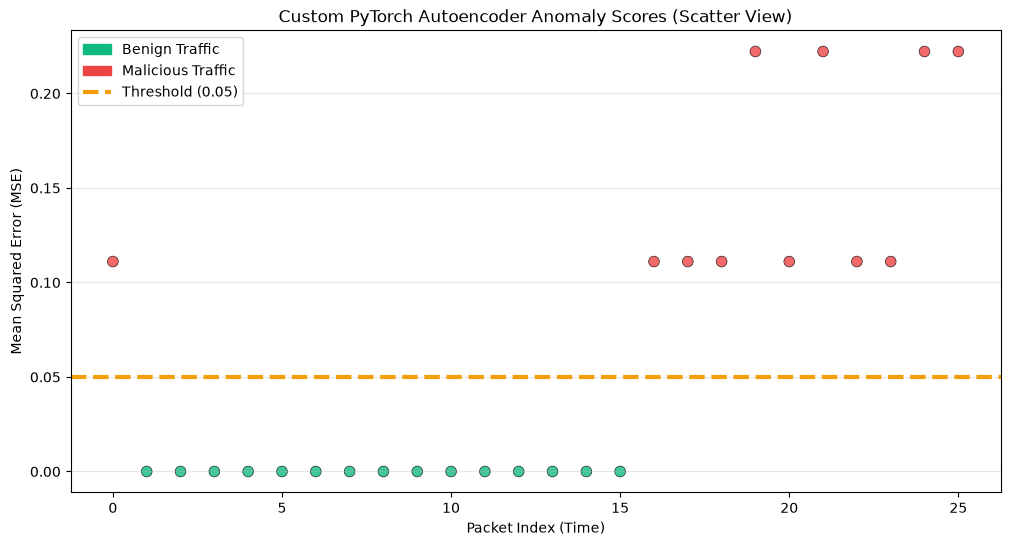

In [10]:
import os
import sys
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Suppress warnings for a clean output
import warnings
warnings.filterwarnings('ignore')

# 1. RE-LOAD DATA
sys.path.append(os.path.abspath("../src"))
import config
from dataset import HubbleDataProcessor
from model import ZeroTrustAutoencoder

print("📊 Loading Test Data for PyTorch Scatter Plot...")
test_processor = HubbleDataProcessor(config.TEST_DATA_PATH)
test_processor.load_and_filter()
test_processor.engineer_features()
df_test = test_processor.get_dataframe()
raw_events = test_processor.raw_data
input_dim = df_test.shape[1]

# 2. LOAD TRAINED PYTORCH MODEL
print("🧠 Loading Trained PyTorch Autoencoder...")
model = ZeroTrustAutoencoder(input_dim)
# Load the weights that we trained earlier in the project
model.load_state_dict(torch.load(config.MODEL_WEIGHTS_PATH))
model.eval() # Set to evaluation mode

# 3. RUN INFERENCE ON ALL TEST PACKETS
# We use reduction='none' so we get the individual error for every single row, not just the average
criterion = nn.MSELoss(reduction='none')
test_tensor = torch.FloatTensor(df_test.values)

with torch.no_grad():
    reconstructed = model(test_tensor)
    # Calculate MSE per row (dim=1 computes the mean across the 9 features for each packet)
    test_errors = criterion(reconstructed, test_tensor).mean(dim=1).numpy()

# 4. SEPARATE AND LABEL DATA
pytorch_normal_scores = []
pytorch_anomaly_scores = []
y_test_labels = [] # 1 for anomaly, 0 for benign

for i in range(len(df_test)):
    context = raw_events[i]
    
    # FIX: Physical L3/L4 drops (Phase 2) are normal policy enforcements, not anomalies.
    # They have 'method' == 'NONE' and 'url' == 'NONE', which made them fail the is_valid_path check previously.
    if context['verdict'] == 'DROPPED':
        pytorch_normal_scores.append(test_errors[i])
        y_test_labels.append(0)
    elif context['method'] in ['POST', 'DELETE'] or df_test.iloc[i]['is_valid_path'] == 0.0:
        pytorch_anomaly_scores.append(test_errors[i])
        y_test_labels.append(1)
    else:
        pytorch_normal_scores.append(test_errors[i])
        y_test_labels.append(0)

print(f"✅ Evaluated {len(df_test)} packets. Generating Scatter Plot...")

# 5. GENERATE SCATTER PLOT
plt.figure(figsize=(12, 6))

indices = range(len(df_test))
# Assign Red to Anomalies and Green to Benign
colors = ['#ef4444' if y_test_labels[i] == 1 else '#10b981' for i in indices]

plt.scatter(indices, test_errors, c=colors, alpha=0.8, s=60, edgecolors='black', linewidths=0.5)

# Draw the SOC Tripwire Threshold
threshold = config.TRIPWIRE_THRESHOLD
plt.axhline(y=threshold, color='#f59e0b', linestyle='--', linewidth=3, 
            label=f'SOC Tripwire ({threshold})')

# Custom legend for scatter colors
benign_patch = mpatches.Patch(color='#10b981', label='Benign Traffic')
malicious_patch = mpatches.Patch(color='#ef4444', label='Malicious Traffic')
line_patch = plt.Line2D([0], [0], color='#f59e0b', linewidth=3, linestyle='--', label=f'Threshold ({threshold})')

plt.title('Custom PyTorch Autoencoder Anomaly Scores (Scatter View)')
plt.xlabel('Packet Index (Time)')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend(handles=[benign_patch, malicious_patch, line_patch])
plt.grid(axis='y', alpha=0.3)
plt.show()